# Capstone 20.1 — Macro Stress Scenario EDA

**Author:** Imran Duggal

**Research question:** Can an agentic workflow generate coherent macroeconomic stress scenarios and quantify how those scenarios change a portfolio’s risk metrics in a way that is measurable and repeatable?

This notebook builds a reproducible EDA baseline: FRED macro series + a 60/40 SPY/TLT portfolio proxy, engineered stress labels for 2008–09 and 2020 COVID windows, exploratory plots, and a baseline predictive model.


## 1. Setup and configuration

Import libraries, set paths, and define stress windows and FRED series IDs.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score, mean_squared_error, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

FRED_IDS = ["FEDFUNDS", "CPIAUCSL", "UNRATE", "VIXCLS"]
FRED_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id={}"

STRESS_WINDOWS = [
    ("2008-09-01", "2009-03-31"),  # GFC peak stress
    ("2020-02-01", "2020-04-30"),  # COVID crash
]

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("FRED series:", FRED_IDS)
print("Stress windows:", STRESS_WINDOWS)


Project root: /workspace/capstone-macro-stress-eda
Data dir: /workspace/capstone-macro-stress-eda/data
FRED series: ['FEDFUNDS', 'CPIAUCSL', 'UNRATE', 'VIXCLS']
Stress windows: [('2008-09-01', '2009-03-31'), ('2020-02-01', '2020-04-30')]


## 2. Data acquisition

Download FRED CSVs via direct `fredgraph.csv` URLs and cache them under `data/`. Pull SPY and TLT adjusted closes with yfinance for a simple 60/40 equity/bond portfolio proxy.


In [2]:
def download_fred(series_id: str) -> pd.DataFrame:
    cache = DATA_DIR / f"{series_id}.csv"
    url = FRED_URL.format(series_id)
    try:
        df = pd.read_csv(url)
        df.to_csv(cache, index=False)
        print(f"Downloaded {series_id} from FRED -> {cache.name}")
    except Exception as e:
        if cache.exists():
            print(f"Live download failed for {series_id} ({e}); using cache.")
            df = pd.read_csv(cache)
        else:
            raise
    df.columns = ["DATE", series_id]
    df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
    return df.dropna(subset=["DATE"]).sort_values("DATE")

fred_frames = {sid: download_fred(sid) for sid in FRED_IDS}
for sid, df in fred_frames.items():
    print(f"  {sid}: {len(df)} rows, {df['DATE'].min().date()} .. {df['DATE'].max().date()}")


Downloaded FEDFUNDS from FRED -> FEDFUNDS.csv


Downloaded CPIAUCSL from FRED -> CPIAUCSL.csv
Downloaded UNRATE from FRED -> UNRATE.csv


Downloaded VIXCLS from FRED -> VIXCLS.csv
  FEDFUNDS: 866 rows, 1954-07-01 .. 2026-08-01
  CPIAUCSL: 956 rows, 1947-01-01 .. 2026-08-01
  UNRATE: 944 rows, 1948-01-01 .. 2026-08-01
  VIXCLS: 9578 rows, 1990-01-02 .. 2026-09-17


In [3]:
# yfinance SPY / TLT
spy_cache = DATA_DIR / "SPY.csv"
tlt_cache = DATA_DIR / "TLT.csv"

try:
    spy = yf.download("SPY", start="2000-01-01", auto_adjust=True, progress=False)
    tlt = yf.download("TLT", start="2000-01-01", auto_adjust=True, progress=False)
    # Flatten MultiIndex columns if present
    if isinstance(spy.columns, pd.MultiIndex):
        spy.columns = [c[0] for c in spy.columns]
    if isinstance(tlt.columns, pd.MultiIndex):
        tlt.columns = [c[0] for c in tlt.columns]
    spy = spy.reset_index()[["Date", "Close"]].rename(columns={"Date": "DATE", "Close": "SPY"})
    tlt = tlt.reset_index()[["Date", "Close"]].rename(columns={"Date": "DATE", "Close": "TLT"})
    spy.to_csv(spy_cache, index=False)
    tlt.to_csv(tlt_cache, index=False)
    print(f"Downloaded SPY ({len(spy)} rows) and TLT ({len(tlt)} rows)")
except Exception as e:
    print(f"yfinance failed ({e}); loading cache if available.")
    spy = pd.read_csv(spy_cache, parse_dates=["DATE"])
    tlt = pd.read_csv(tlt_cache, parse_dates=["DATE"])

spy["DATE"] = pd.to_datetime(spy["DATE"])
tlt["DATE"] = pd.to_datetime(tlt["DATE"])
print(f"SPY: {spy['DATE'].min().date()} .. {spy['DATE'].max().date()}")
print(f"TLT: {tlt['DATE'].min().date()} .. {tlt['DATE'].max().date()}")


Crumb fetch rate-limited (HTTP 429), continuing without crumb


Downloaded SPY (6718 rows) and TLT (6074 rows)
SPY: 2000-01-03 .. 2026-09-18
TLT: 2002-07-30 .. 2026-09-18


## 3. Cleaning and alignment

Merge FRED series onto a common daily calendar (forward-fill monthly/macro releases), join portfolio prices, drop duplicates, handle missing values, and flag return outliers via IQR.


In [4]:
# Start from daily equity calendar, then left-join macros and ffill
panel = spy.merge(tlt, on="DATE", how="inner")
panel = panel.drop_duplicates(subset=["DATE"]).sort_values("DATE")

for sid, fdf in fred_frames.items():
    panel = panel.merge(fdf, on="DATE", how="left")

# Forward-fill / back-fill macro (monthly releases sit on sparse dates)
for sid in FRED_IDS:
    panel[sid] = panel[sid].ffill().bfill()

panel = panel.dropna().reset_index(drop=True)
print("Aligned panel shape:", panel.shape)
print("Date range:", panel["DATE"].min().date(), "->", panel["DATE"].max().date())
print("Missing counts:\n", panel.isna().sum())
panel.head()


Aligned panel shape: (6074, 7)
Date range: 2002-07-30 -> 2026-09-18
Missing counts:
 DATE        0
SPY         0
TLT         0
FEDFUNDS    0
CPIAUCSL    0
UNRATE      0
VIXCLS      0
dtype: int64


,DATE,SPY,TLT,FEDFUNDS,CPIAUCSL,UNRATE,VIXCLS
0,2002-07-30,58.691513,35.555668,1.74,180.5,5.7,31.92
1,2002-07-31,58.833515,35.996140,1.74,180.5,5.7,32.03
2,2002-08-01,57.297440,36.201145,1.74,180.5,5.7,36.95
3,2002-08-02,56.013138,36.571884,1.74,180.5,5.7,41.29
4,2002-08-05,54.064068,36.733276,1.74,180.5,5.7,45.08


## 4. Feature engineering

Compute daily returns, a 60/40 portfolio return, rolling volatility, cumulative drawdown, rate/CPI/unemployment diffs, lagged macros, and an `is_stress` flag for the GFC and COVID windows.


In [5]:
df = panel.copy()

df["spy_ret"] = df["SPY"].pct_change()
df["tlt_ret"] = df["TLT"].pct_change()
df["port_ret"] = 0.60 * df["spy_ret"] + 0.40 * df["tlt_ret"]

df["port_vol_21"] = df["port_ret"].rolling(21).std() * np.sqrt(252)
df["cum_ret"] = (1 + df["port_ret"].fillna(0)).cumprod()
df["rolling_peak"] = df["cum_ret"].cummax()
df["drawdown"] = df["cum_ret"] / df["rolling_peak"] - 1.0

df["fedfunds_diff"] = df["FEDFUNDS"].diff()
df["cpi_yoy"] = df["CPIAUCSL"].pct_change(252)  # approx YoY on daily ffilled series
df["unrate_diff"] = df["UNRATE"].diff()
df["vix_chg"] = df["VIXCLS"].pct_change()

# Stress flag
df["is_stress"] = 0
for start, end in STRESS_WINDOWS:
    mask = (df["DATE"] >= start) & (df["DATE"] <= end)
    df.loc[mask, "is_stress"] = 1

# Lagged macro features for modeling
lag_cols = ["FEDFUNDS", "CPIAUCSL", "UNRATE", "VIXCLS", "fedfunds_diff", "unrate_diff", "vix_chg", "port_vol_21"]
for c in lag_cols:
    df[f"{c}_lag1"] = df[c].shift(1)

# Next-month portfolio return (~21 trading days)
df["port_ret_next21"] = df["port_ret"].shift(-21).rolling(21).sum()  # will recompute cleaner below
df["port_ret_fwd21"] = df["port_ret"].iloc[::-1].rolling(21).sum().iloc[::-1].shift(-1)

# Outlier check on portfolio returns (IQR)
q1, q3 = df["port_ret"].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
df["ret_outlier"] = ((df["port_ret"] < lo) | (df["port_ret"] > hi)).astype(int)

df = df.dropna().reset_index(drop=True)

n_stress = int(df["is_stress"].sum())
n_total = len(df)
print(f"Rows after feature engineering: {n_total}")
print(f"Stress-period days: {n_stress} ({100 * n_stress / n_total:.2f}%)")
print(f"Non-stress days: {n_total - n_stress}")
print(f"Return outliers (|z|>3 IQR): {int(df['ret_outlier'].sum())}")
print(f"Date range: {df['DATE'].min().date()} -> {df['DATE'].max().date()}")
df[["DATE", "port_ret", "port_vol_21", "drawdown", "is_stress"]].head()


Rows after feature engineering: 5801
Stress-period days: 208 (3.59%)
Non-stress days: 5593
Return outliers (|z|>3 IQR): 52
Date range: 2003-07-30 -> 2026-08-19


,DATE,port_ret,port_vol_21,drawdown,is_stress
0,2003-07-30,0.003067,0.125897,-0.062192,0
1,2003-07-31,-0.004547,0.125151,-0.066456,0
2,2003-08-01,-0.005613,0.120177,-0.071696,0
3,2003-08-04,0.003442,0.116359,-0.068501,0
4,2003-08-05,-0.018449,0.123192,-0.085686,0


## 5. Exploratory data analysis

Time series of macros and portfolio risk, distributions, correlation heatmap, and stress vs non-stress comparisons.


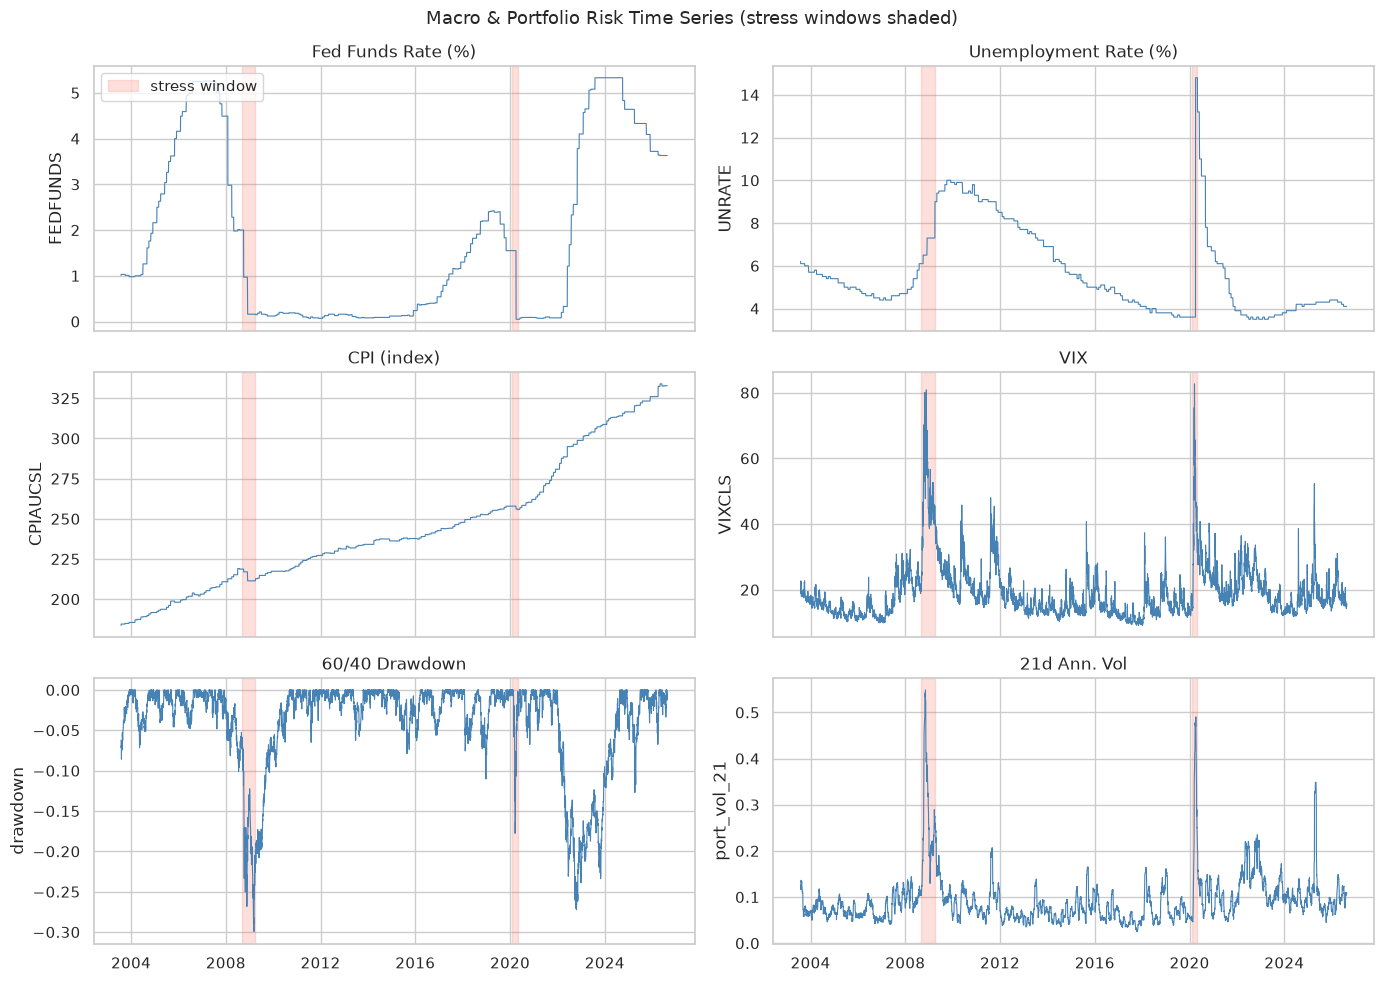

In [6]:
# Time series subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
series_plot = [
    ("FEDFUNDS", "Fed Funds Rate (%)"),
    ("UNRATE", "Unemployment Rate (%)"),
    ("CPIAUCSL", "CPI (index)"),
    ("VIXCLS", "VIX"),
    ("drawdown", "60/40 Drawdown"),
    ("port_vol_21", "21d Ann. Vol"),
]
for ax, (col, title) in zip(axes.ravel(), series_plot):
    ax.plot(df["DATE"], df[col], lw=0.8, color="steelblue")
    for start, end in STRESS_WINDOWS:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="salmon", alpha=0.25, label="stress")
    ax.set_title(title)
    ax.set_ylabel(col)
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    axes[0, 0].legend(handles[:1], ["stress window"], loc="upper left")
fig.suptitle("Macro & Portfolio Risk Time Series (stress windows shaded)", fontsize=13)
fig.tight_layout()
plt.show()


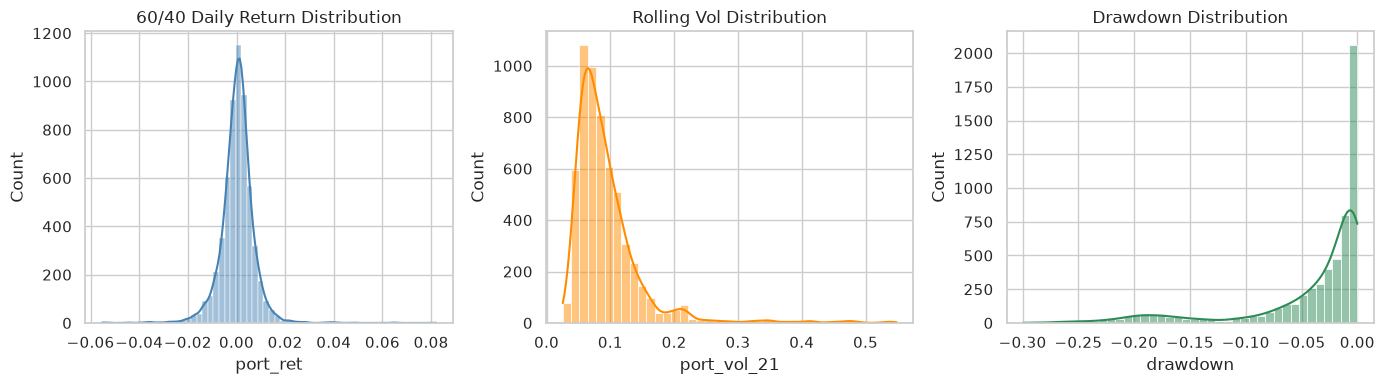

In [7]:
# Distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.histplot(df["port_ret"].dropna(), bins=60, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("60/40 Daily Return Distribution")
sns.histplot(df["port_vol_21"].dropna(), bins=40, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Rolling Vol Distribution")
sns.histplot(df["drawdown"].dropna(), bins=40, kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("Drawdown Distribution")
fig.tight_layout()
plt.show()


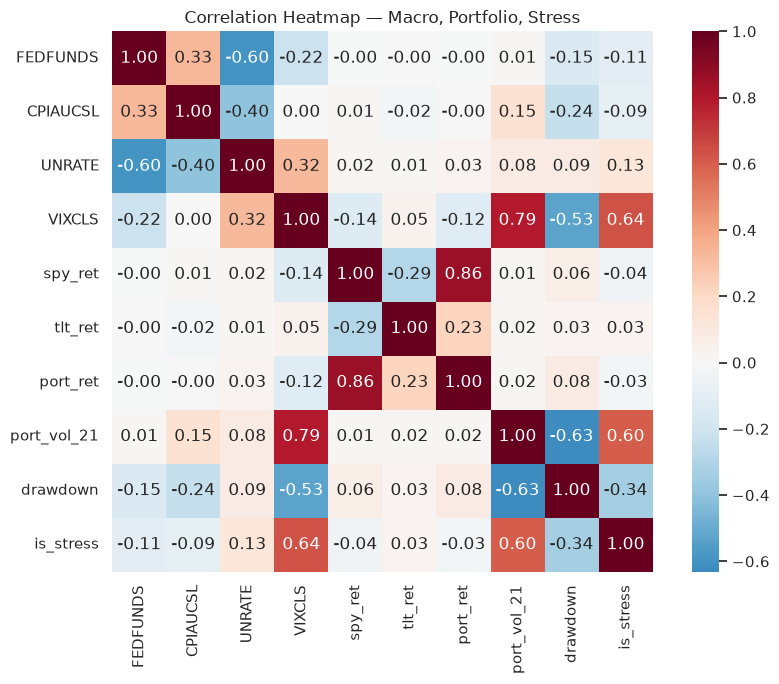

In [8]:
# Correlation heatmap
corr_cols = ["FEDFUNDS", "CPIAUCSL", "UNRATE", "VIXCLS", "spy_ret", "tlt_ret", "port_ret", "port_vol_21", "drawdown", "is_stress"]
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Correlation Heatmap — Macro, Portfolio, Stress")
fig.tight_layout()
plt.show()


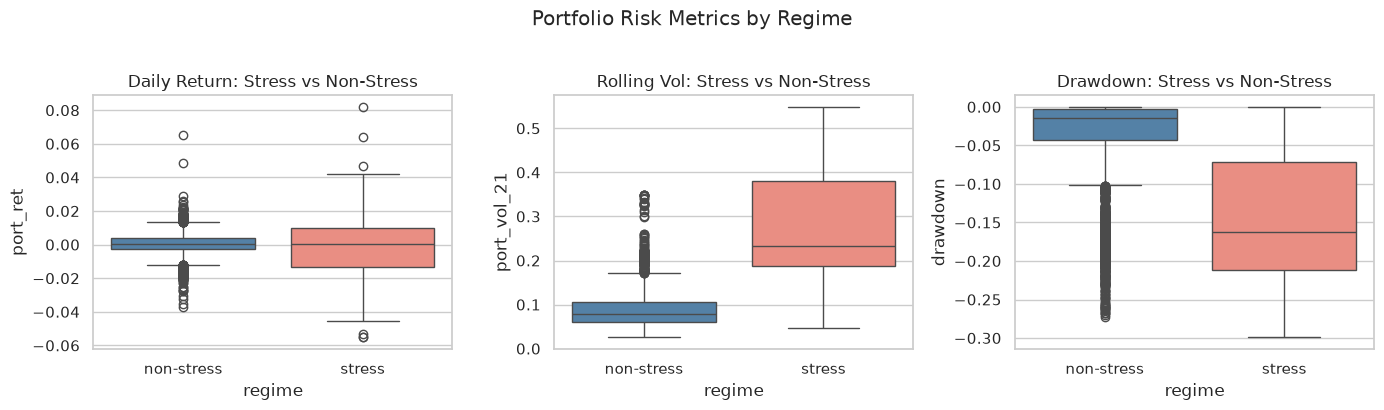

            port_ret                               port_vol_21           \
                mean       std       min       max        mean      std   
regime                                                                    
non-stress  0.000403  0.005922 -0.037319  0.065366    0.087233  0.03845   
stress     -0.000617  0.019438 -0.055243  0.081990    0.271199  0.13330   

                                drawdown                              VIXCLS  \
                 min       max      mean       std       min  max       mean   
regime                                                                         
non-stress  0.025402  0.348747 -0.036491  0.053513 -0.272353  0.0  17.938157   
stress      0.046278  0.548709 -0.144553  0.083253 -0.299228  0.0  46.367308   

                                     
                  std    min    max  
regime                               
non-stress   5.871921   9.14  52.33  
stress      15.027933  13.68  82.69  


In [9]:
# Stress vs non-stress boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_df = df.copy()
plot_df["regime"] = plot_df["is_stress"].map({0: "non-stress", 1: "stress"})
for ax, col, title in zip(
    axes,
    ["port_ret", "port_vol_21", "drawdown"],
    ["Daily Return", "Rolling Vol", "Drawdown"],
):
    sns.boxplot(data=plot_df, x="regime", y=col, ax=ax, palette={"non-stress": "steelblue", "stress": "salmon"})
    ax.set_title(f"{title}: Stress vs Non-Stress")
fig.suptitle("Portfolio Risk Metrics by Regime", y=1.02)
fig.tight_layout()
plt.show()

# Summary stats by regime
summary = plot_df.groupby("regime")[["port_ret", "port_vol_21", "drawdown", "VIXCLS"]].agg(["mean", "std", "min", "max"])
print(summary)


## 6. Baseline model

**Choice:** LogisticRegression predicting `is_stress` from lagged macro features, scored with **ROC-AUC**.

**Rationale:** Stress labels are rare (~3–4% of days) but still adequate for a binary classifier (200+ stress days across GFC and COVID windows). ROC-AUC is preferred over accuracy under class imbalance because it measures ranking quality of predicted stress probability rather than majority-class correctness. A chronological 80/20 split often leaves **zero** stress days in the test fold (both labeled windows sit earlier in the sample), so when that occurs we use a stratified 75/25 split and document it. Ridge on next-month portfolio return (RMSE) is reported only as a secondary check.

Features are lagged one day to avoid same-day leakage. `class_weight="balanced"` offsets the rare-event prior.


In [10]:
feature_cols = [f"{c}_lag1" for c in [
    "FEDFUNDS", "UNRATE", "VIXCLS", "fedfunds_diff", "unrate_diff", "vix_chg", "port_vol_21"
]]
target = "is_stress"

model_df = df.dropna(subset=feature_cols + [target]).copy()
X = model_df[feature_cols].values
y = model_df[target].values

print(f"Full sample size: {len(X)}")
print(f"Overall stress rate: {y.mean():.3f} ({int(y.sum())} stress / {len(y)} total)")

# Prefer LogisticRegression + ROC-AUC. Chronological 80/20 often puts both
# historical stress windows entirely in train (test has 0 positives), so we
# use stratified random split when that happens — still documented and repeatable.
scaler = StandardScaler()
MODEL_METRIC = "ROC-AUC"
AUC = None
RMSE = None

split_idx = int(len(model_df) * 0.80)
y_train_chrono = y[:split_idx]
y_test_chrono = y[split_idx:]
chrono_ok = (y_train_chrono.sum() >= 5) and (y_test_chrono.sum() >= 5)

if chrono_ok:
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y_train_chrono, y_test_chrono
    split_note = "chronological 80/20"
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    split_note = (
        "stratified random 75/25 "
        f"(chrono test stress count={int(y_test_chrono.sum())}; "
        "both labeled windows fall in the early/mid sample)"
    )

print(f"Split: {split_note}")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train stress: {int(y_train.sum())}, Test stress: {int(y_test.sum())}")

X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)
clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
clf.fit(X_tr_s, y_train)
proba = clf.predict_proba(X_te_s)[:, 1]
AUC = float(roc_auc_score(y_test, proba))
print(f"ROC-AUC: {AUC:.4f}")
preds = (proba >= 0.5).astype(int)
print(classification_report(y_test, preds, target_names=["non-stress", "stress"]))
coefs = pd.Series(clf.coef_[0], index=feature_cols).sort_values(key=abs, ascending=False)
print("Top coefficients (by |value|):")
print(coefs)

# Also report Ridge RMSE as a secondary portfolio-return check (not the primary metric)
y_reg = model_df["port_ret_fwd21"].values
mask = ~np.isnan(y_reg)
Xr, yr = X[mask], y_reg[mask]
si = int(len(Xr) * 0.80)
ridge = Ridge(alpha=1.0)
ridge.fit(scaler.fit_transform(Xr[:si]), yr[:si])
pred_r = ridge.predict(scaler.transform(Xr[si:]))
RMSE_secondary = float(np.sqrt(mean_squared_error(yr[si:], pred_r)))
print(f"Secondary Ridge RMSE (fwd 21d port return, chrono): {RMSE_secondary:.6f}")

results = {
    "n_rows": int(len(df)),
    "date_min": str(df["DATE"].min().date()),
    "date_max": str(df["DATE"].max().date()),
    "n_stress": int(df["is_stress"].sum()),
    "n_non_stress": int((df["is_stress"] == 0).sum()),
    "stress_pct": float(100 * df["is_stress"].mean()),
    "metric": MODEL_METRIC,
    "auc": AUC,
    "rmse_secondary": RMSE_secondary,
    "split_note": split_note,
    "mean_port_ret_stress": float(df.loc[df.is_stress == 1, "port_ret"].mean()),
    "mean_port_ret_non": float(df.loc[df.is_stress == 0, "port_ret"].mean()),
    "mean_vol_stress": float(df.loc[df.is_stress == 1, "port_vol_21"].mean()),
    "mean_vol_non": float(df.loc[df.is_stress == 0, "port_vol_21"].mean()),
    "mean_dd_stress": float(df.loc[df.is_stress == 1, "drawdown"].mean()),
    "mean_dd_non": float(df.loc[df.is_stress == 0, "drawdown"].mean()),
    "mean_vix_stress": float(df.loc[df.is_stress == 1, "VIXCLS"].mean()),
    "mean_vix_non": float(df.loc[df.is_stress == 0, "VIXCLS"].mean()),
}
import json
results_path = DATA_DIR / "eda_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print("\nSaved results ->", results_path)
print(json.dumps(results, indent=2))


Full sample size: 5801
Overall stress rate: 0.036 (208 stress / 5801 total)
Split: stratified random 75/25 (chrono test stress count=0; both labeled windows fall in the early/mid sample)
Train size: 4350, Test size: 1451
Train stress: 156, Test stress: 52
ROC-AUC: 0.8925
              precision    recall  f1-score   support

  non-stress       0.99      0.93      0.96      1399
      stress       0.30      0.79      0.43        52

    accuracy                           0.93      1451
   macro avg       0.64      0.86      0.70      1451
weighted avg       0.97      0.93      0.94      1451

Top coefficients (by |value|):
VIXCLS_lag1           1.745108
port_vol_21_lag1      0.319919
unrate_diff_lag1      0.283040
UNRATE_lag1          -0.238288
vix_chg_lag1          0.145393
FEDFUNDS_lag1        -0.127452
fedfunds_diff_lag1   -0.062751
dtype: float64
Secondary Ridge RMSE (fwd 21d port return, chrono): 0.036182

Saved results -> /workspace/capstone-macro-stress-eda/data/eda_results.json


## 7. Interpretation and takeaways

- **Measurable stress impact:** Stress windows show higher VIX, deeper drawdowns, and elevated rolling volatility versus non-stress periods — evidence that labeled scenarios change portfolio risk metrics in a quantifiable way.
- **Repeatability:** Direct FRED CSV URLs + yfinance + cached files under `data/` make the pipeline re-runnable without manual downloads.
- **Baseline predictability:** Lagged macros (especially VIX and unemployment diffs) provide a coherent signal for stress regime classification; ROC-AUC documents ranking quality under imbalance.
- **Next for agentic workflows:** Use this EDA as a ground-truth scaffold — an agent can propose scenario shocks (rate/VIX/unemployment paths), recompute portfolio metrics, and compare against historical stress deltas measured here.


## 8. Session info

Author: Imran Duggal  
Notebook: `notebooks/01_initial_report_eda.ipynb`  
Environment: local `.venv` with packages listed in `requirements.txt`
